<a href="https://colab.research.google.com/github/idanidan29/Fake-News-Detection-Model/blob/main/Fake_News_Detection_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install textblob --quiet
!python -m nltk.downloader stopwords wordnet omw-1.4 --quiet

import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, roc_auc_score, RocCurveDisplay
)
from scipy.sparse import hstack, csr_matrix

import keras
from keras import layers

STOP_WORDS = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

print("Setup complete.")


<frozen runpy>:128: RuntimeWarning: 'nltk.downloader' found in sys.modules after import of package 'nltk', but prior to execution of 'nltk.downloader'; this may result in unpredictable behaviour
Setup complete.


## 1 · Load & Deduplicate


Raw rows loaded: 60,843
Columns: ['Unnamed: 0', 'title', 'text', 'label']
After dedup: 54,308 rows (removed 6,018)
Dropping 4 rows with corrupted labels (out of 54,308 — 0.01% of data)

Final label distribution:
label
0    29364
1    24940
Name: count, dtype: int64

Total clean rows: 54,304

Dataset balanced — using all 54,304 rows

Training pool: 54,304 rows
label
0    29364
1    24940
Name: count, dtype: int64


/tmp/ipykernel_10220/1754281740.py:79: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(); plt.show()


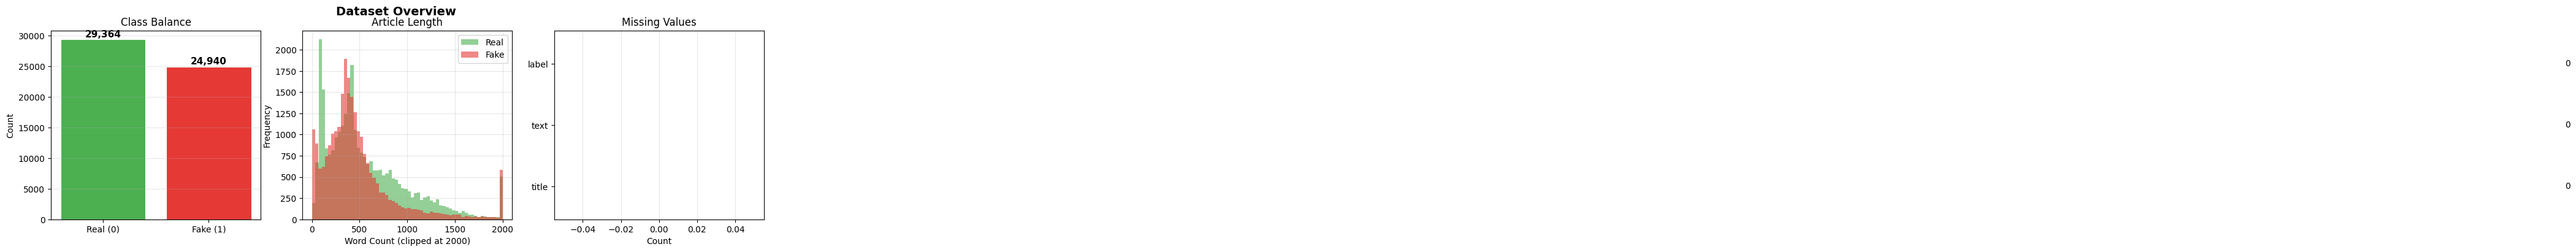

In [15]:
# ── Cell 1: Load & Deduplicate ──────────────────────────────────────────
df = pd.read_csv(
    "/content/sample_data/WELFake_Dataset.csv",
    engine="python",
    on_bad_lines="skip",
)

print(f"Raw rows loaded: {len(df):,}")
print(f"Columns: {list(df.columns)}")

df.dropna(subset=["title", "text"], inplace=True)
df["full_content"] = df["title"].astype(str) + " " + df["text"].astype(str)

# Deduplicate
before = len(df)
df.drop_duplicates(subset="full_content", inplace=True)
print(f"After dedup: {len(df):,} rows (removed {before - len(df):,})")

# Clean label — coerce to numeric, keep ONLY 0 and 1
# A few dozen rows have text in the label column due to CSV misalignment — drop just those
df["label"] = pd.to_numeric(df["label"], errors="coerce")
bad_labels = df["label"].isna() | ~df["label"].isin([0, 1])
print(f"Dropping {bad_labels.sum()} rows with corrupted labels "
      f"(out of {len(df):,} — {100*bad_labels.sum()/len(df):.2f}% of data)")

df = df[~bad_labels].copy()
df["label"] = df["label"].astype(int)

label_counts = df["label"].value_counts().sort_index()
print(f"\nFinal label distribution:\n{label_counts}")
print(f"\nTotal clean rows: {len(df):,}")

# Use the FULL dataset — no sampling cap
# Only balance if one class is >20% larger than the other
min_c = int(label_counts.min())
max_c = int(label_counts.max())

if max_c / min_c > 1.2:
    print(f"\nImbalance detected — downsampling majority to {min_c:,}")
    df_sample = (
        df.groupby("label", group_keys=False)
          .apply(lambda g: g.sample(min_c, random_state=42), include_groups=True)
          .reset_index(drop=True)
    )
else:
    print(f"\nDataset balanced — using all {len(df):,} rows")
    df_sample = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nTraining pool: {len(df_sample):,} rows")
print(df_sample["label"].value_counts().sort_index())

# ── VIZ 1: Dataset Overview ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Dataset Overview", fontsize=14, fontweight="bold")

label_counts_s = df_sample["label"].value_counts().sort_index()
bars = axes[0].bar(["Real (0)", "Fake (1)"], label_counts_s.values,
                    color=["#4CAF50", "#E53935"], edgecolor="white", linewidth=0.8)
for bar, val in zip(bars, label_counts_s.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f"{val:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[0].set_title("Class Balance"); axes[0].set_ylabel("Count"); axes[0].grid(axis="y", alpha=0.3)

df_sample["_wc"] = df_sample["full_content"].str.split().str.len()
for label, color, name in [(0, "#4CAF50", "Real"), (1, "#E53935", "Fake")]:
    axes[1].hist(df_sample[df_sample["label"]==label]["_wc"].clip(upper=2000),
                 bins=60, alpha=0.6, color=color, label=name)
axes[1].set_title("Article Length"); axes[1].set_xlabel("Word Count (clipped at 2000)")
axes[1].set_ylabel("Frequency"); axes[1].legend(); axes[1].grid(alpha=0.3)

missing = df[["title","text","label"]].isnull().sum().reset_index()
missing.columns = ["Column","Missing"]
axes[2].barh(missing["Column"], missing["Missing"], color="#5C6BC0")
axes[2].set_title("Missing Values"); axes[2].set_xlabel("Count")
for i, v in enumerate(missing["Missing"]):
    axes[2].text(v+1, i, str(v), va="center", fontsize=10)
axes[2].grid(axis="x", alpha=0.3)

plt.tight_layout(); plt.show()
df_sample.drop(columns=["_wc"], inplace=True)

## 2 · Text Preprocessing

- **Numbers → `<NUM>` token** (preserves statistical signals instead of discarding them)
- **Stopword removal** (NLTK)
- **Lemmatization** (WordNetLemmatizer)
- **Sentiment extracted from raw text** before cleaning (needs punctuation intact)
- **Handcrafted features** extracted from raw text: length, caps ratio, punctuation density

Computing sentiment scores (this may take ~1 min)...
Cleaning text...


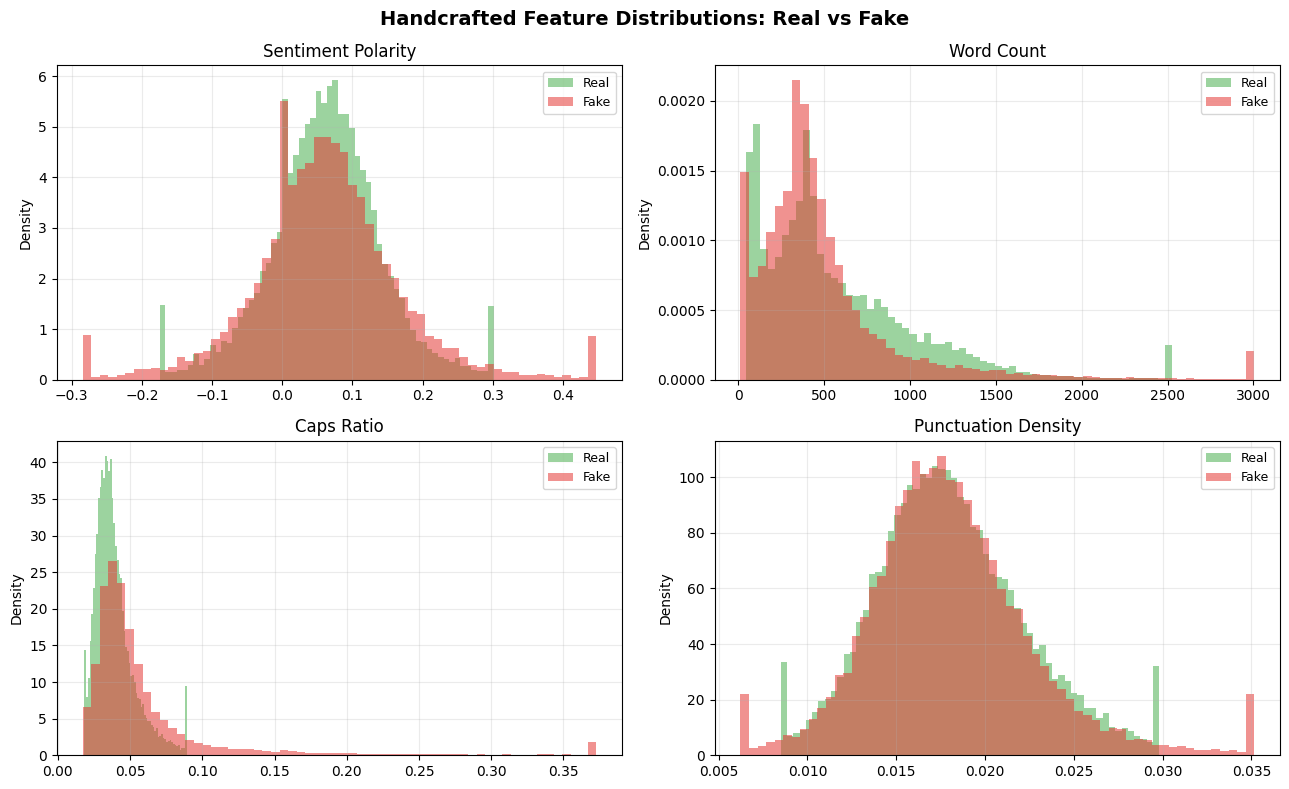

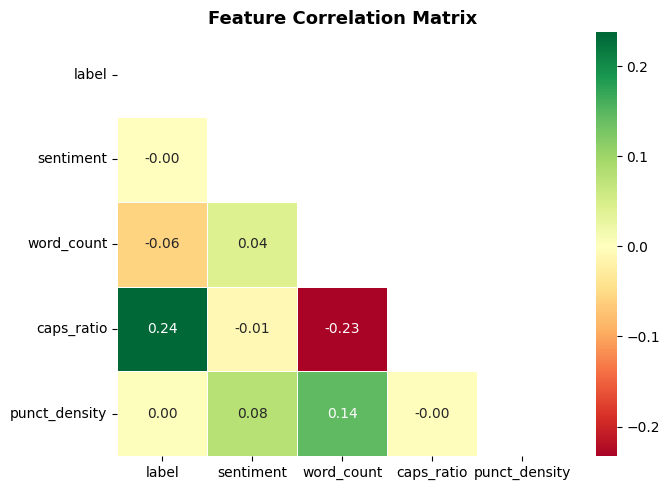


Sample — Before: The Clinton FBI Investigation Just Got Real The FBI is now “actively and aggressively” probing into Clinton Foundation corruption. The Clinton campaign is going down. The FBI seems to be sick of the D

Sample — After:  clinton fbi investigation got real fbi actively aggressively probing clinton foundation corruption clinton campaign going fbi seems sick doj favoritism via yournewswire two separate source told fox ne


In [16]:
# ── Cell 2: Feature Extraction + Improved clean_text ────────────────────

# IMPROVEMENT 3: Sentiment from RAW text (needs punctuation — before cleaning)
print("Computing sentiment scores (this may take ~1 min)...")
df_sample["sentiment"] = df_sample["full_content"].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

# IMPROVEMENT 4: Handcrafted stylometric features
df_sample["char_len"]      = df_sample["full_content"].str.len()
df_sample["word_count"]    = df_sample["full_content"].str.split().str.len()
df_sample["caps_ratio"]    = df_sample["full_content"].apply(
    lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1)
)
df_sample["punct_density"] = df_sample["full_content"].apply(
    lambda x: sum(1 for c in x if c in "!?.,;:") / max(len(x), 1)
)

# IMPROVEMENT 5: Better clean_text
def clean_text(text):
    text = str(text)
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"\d+", "<NUM>", text)
    text = re.sub(r"[^a-zA-Z\s<>]", "", text)
    text = text.lower().strip()
    tokens = [lemmatizer.lemmatize(w) for w in text.split() if w not in STOP_WORDS]
    return " ".join(tokens)

print("Cleaning text...")
df_sample["clean_text"] = df_sample["full_content"].apply(clean_text)

# ── VIZ 2: Handcrafted Feature Distributions by Label ─────────────────────
NUM_FEATS_VIZ = ["sentiment", "word_count", "caps_ratio", "punct_density"]
feat_labels   = ["Sentiment Polarity", "Word Count", "Caps Ratio", "Punctuation Density"]
colors = {0: "#4CAF50", 1: "#E53935"}
label_names = {0: "Real", 1: "Fake"}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle("Handcrafted Feature Distributions: Real vs Fake", fontsize=14, fontweight="bold")

for ax, feat, flabel in zip(axes.flat, NUM_FEATS_VIZ, feat_labels):
    for label in [0, 1]:
        vals = df_sample[df_sample["label"] == label][feat]
        # clip extremes for cleaner plot
        lo, hi = vals.quantile(0.01), vals.quantile(0.99)
        vals = vals.clip(lo, hi)
        ax.hist(vals, bins=60, alpha=0.55, color=colors[label],
                label=label_names[label], density=True)
    ax.set_title(flabel)
    ax.set_ylabel("Density")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

# ── VIZ 3: Feature Correlation Heatmap ────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
corr_cols = ["label", "sentiment", "word_count", "caps_ratio", "punct_density"]
corr = df_sample[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            mask=mask, ax=ax, linewidths=0.5,
            annot_kws={"size": 10})
ax.set_title("Feature Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nSample — Before:", df_sample["full_content"].iloc[0][:200])
print("\nSample — After: ", df_sample["clean_text"].iloc[0][:200])


## 3 · Train / Val / Test Split
**IMPROVEMENT 6:** Split happens *before* fitting any vectorizer or scaler to prevent data leakage.

Split: **70% train / 15% val / 15% test**, stratified on label.

Raw label value counts:
label
0    29364
1    24940
Name: count, dtype: int64
Train : 38,034 | Val : 8,124 | Test : 8,146


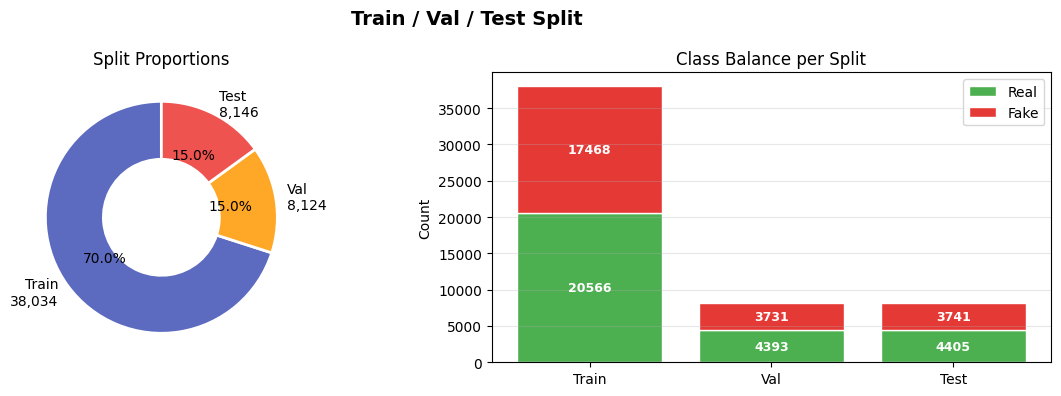

In [17]:
# ── Cell 3: Train / Val / Test Split ────────────────────────────────────

# Safety: clean label column
print("Raw label value counts:")
print(df_sample["label"].value_counts())

df_sample["label"] = pd.to_numeric(df_sample["label"], errors="coerce")
df_sample = df_sample[df_sample["label"].isin([0, 1])].copy()
df_sample["label"] = df_sample["label"].astype(int)

X_text = df_sample["clean_text"]
y      = df_sample["label"]
NUM_FEATS = ["sentiment", "char_len", "word_count", "caps_ratio", "punct_density"]
X_num = df_sample[NUM_FEATS]

X_text_tv, X_text_test, X_num_tv, X_num_test, y_tv, y_test = train_test_split(
    X_text, X_num, y, test_size=0.15, random_state=42, stratify=y
)
X_text_train, X_text_val, X_num_train, X_num_val, y_train, y_val = train_test_split(
    X_text_tv, X_num_tv, y_tv, test_size=0.176, random_state=42, stratify=y_tv
)

print(f"Train : {len(y_train):,} | Val : {len(y_val):,} | Test : {len(y_test):,}")

# ── VIZ 4: Split Summary ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Train / Val / Test Split", fontsize=14, fontweight="bold")

# 4a. Proportions donut
sizes  = [len(y_train), len(y_val), len(y_test)]
labels = [f"Train\n{len(y_train):,}", f"Val\n{len(y_val):,}", f"Test\n{len(y_test):,}"]
wedge_colors = ["#5C6BC0", "#FFA726", "#EF5350"]
wedges, texts, autotexts = axes[0].pie(
    sizes, labels=labels, colors=wedge_colors,
    autopct="%1.1f%%", startangle=90,
    wedgeprops=dict(width=0.5, edgecolor="white", linewidth=2),
    textprops=dict(fontsize=10)
)
axes[0].set_title("Split Proportions")

# 4b. Class balance per split — stacked bars
splits = {"Train": y_train, "Val": y_val, "Test": y_test}
real_counts = [v.value_counts().get(0, 0) for v in splits.values()]
fake_counts = [v.value_counts().get(1, 0) for v in splits.values()]
x = np.arange(3)
b1 = axes[1].bar(x, real_counts, color="#4CAF50", label="Real", edgecolor="white")
b2 = axes[1].bar(x, fake_counts, bottom=real_counts, color="#E53935", label="Fake", edgecolor="white")
axes[1].set_xticks(x); axes[1].set_xticklabels(splits.keys())
axes[1].set_ylabel("Count"); axes[1].set_title("Class Balance per Split")
axes[1].legend(); axes[1].grid(axis="y", alpha=0.3)
for bar, val in zip(b1, real_counts):
    axes[1].text(bar.get_x()+bar.get_width()/2, val/2, str(val),
                 ha="center", va="center", color="white", fontsize=9, fontweight="bold")
for bar, rc, val in zip(b2, real_counts, fake_counts):
    axes[1].text(bar.get_x()+bar.get_width()/2, rc+val/2, str(val),
                 ha="center", va="center", color="white", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()


## 4 · TF-IDF Feature Engineering
Vectorizer is **fit on train only**, then applied (transform-only) to val and test.

Feature matrix shape (train): (38034, 50005)


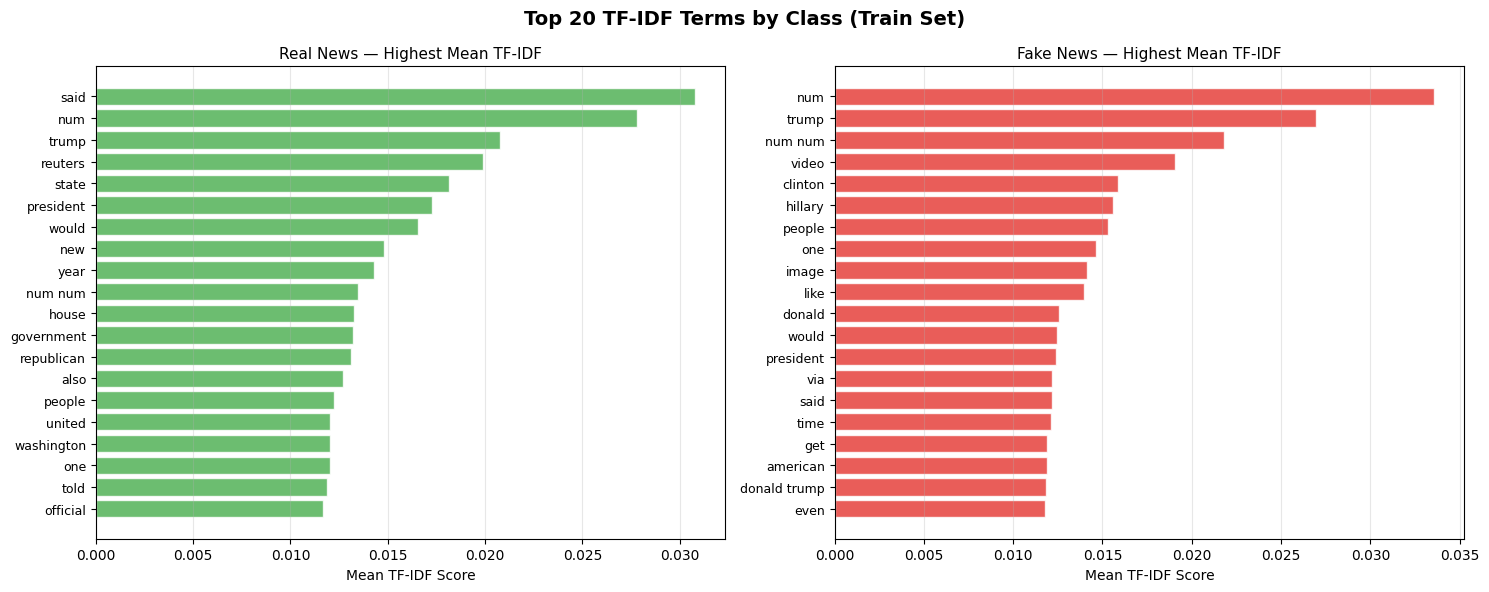

In [18]:
# ── Cell 4: TF-IDF + Numeric Feature Matrix ──────────────────────────────
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50_000,
    sublinear_tf=True,
    min_df=3,
)
X_tfidf_train = tfidf.fit_transform(X_text_train)
X_tfidf_val   = tfidf.transform(X_text_val)
X_tfidf_test  = tfidf.transform(X_text_test)

scaler = StandardScaler()
X_num_train_s = scaler.fit_transform(X_num_train)
X_num_val_s   = scaler.transform(X_num_val)
X_num_test_s  = scaler.transform(X_num_test)

X_train_full = hstack([X_tfidf_train, csr_matrix(X_num_train_s)])
X_val_full   = hstack([X_tfidf_val,   csr_matrix(X_num_val_s)])
X_test_full  = hstack([X_tfidf_test,  csr_matrix(X_num_test_s)])

print(f"Feature matrix shape (train): {X_train_full.shape}")

# ── VIZ 5: Top TF-IDF Terms per Class ────────────────────────────────────
# Compute mean TF-IDF score per term for each class separately
feature_names_arr = np.array(tfidf.get_feature_names_out())
train_idx = X_text_train.index

y_train_arr = y_train.values
real_mask = y_train_arr == 0
fake_mask = y_train_arr == 1

mean_real = np.asarray(X_tfidf_train[real_mask].mean(axis=0)).flatten()
mean_fake = np.asarray(X_tfidf_train[fake_mask].mean(axis=0)).flatten()

top_n = 20
top_real_idx = mean_real.argsort()[-top_n:][::-1]
top_fake_idx = mean_fake.argsort()[-top_n:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Top 20 TF-IDF Terms by Class (Train Set)", fontsize=14, fontweight="bold")

for ax, indices, means, title, color in [
    (axes[0], top_real_idx, mean_real, "Real News — Highest Mean TF-IDF", "#4CAF50"),
    (axes[1], top_fake_idx, mean_fake, "Fake News — Highest Mean TF-IDF", "#E53935"),
]:
    terms = feature_names_arr[indices]
    scores = means[indices]
    y_pos = np.arange(len(terms))
    bars = ax.barh(y_pos, scores, color=color, alpha=0.82, edgecolor="white")
    ax.set_yticks(y_pos); ax.set_yticklabels(terms, fontsize=9)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Mean TF-IDF Score")
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()


## 5 · Baseline — Logistic Regression
Fast, interpretable, and surprisingly strong on WELFake. Sets our performance floor.

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


=== Logistic Regression — Validation Set ===
              precision    recall  f1-score   support

        Real       0.97      0.97      0.97      4393
        Fake       0.97      0.96      0.96      3731

    accuracy                           0.97      8124
   macro avg       0.97      0.97      0.97      8124
weighted avg       0.97      0.97      0.97      8124

ROC-AUC: 0.9943


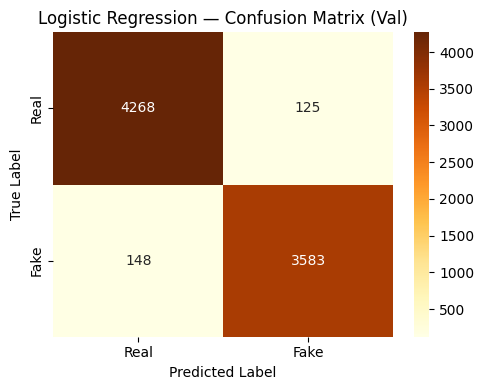

In [21]:
# ── Cell 5: Logistic Regression ─────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, C=1.0, solver="saga", n_jobs=-1)
lr.fit(X_train_full, y_train)

y_val_pred = lr.predict(X_val_full)
y_val_prob = lr.predict_proba(X_val_full)[:, 1]

print("=== Logistic Regression — Validation Set ===")
print(classification_report(y_val, y_val_pred, target_names=["Real", "Fake"]))
print(f"ROC-AUC: {roc_auc_score(y_val, y_val_prob):.4f}")

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="YlOrBr",
            xticklabels=["Real", "Fake"],
            yticklabels=["Real", "Fake"], ax=ax)
ax.set_title("Logistic Regression — Confusion Matrix (Val)")
ax.set_ylabel("True Label")
ax.set_xlabel("Predicted Label")
plt.tight_layout()
plt.show()


## 6 · Precision-Recall & ROC Curves

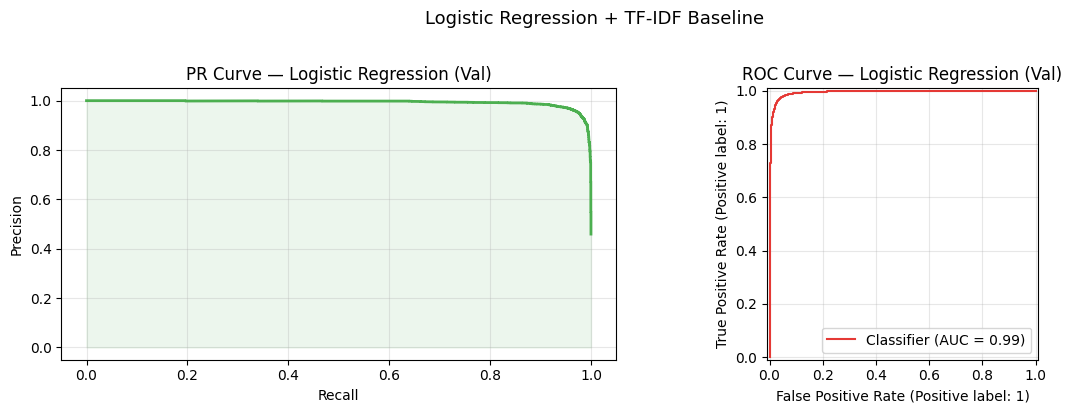

In [22]:
# ── Cell 6: PR & ROC Curves ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Precision-Recall curve
prec, rec, _ = precision_recall_curve(y_val, y_val_prob)
axes[0].plot(rec, prec, color="#4CAF50", lw=2)
axes[0].fill_between(rec, prec, alpha=0.1, color="#4CAF50")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("PR Curve — Logistic Regression (Val)")
axes[0].grid(alpha=0.3)

# ROC curve
RocCurveDisplay.from_predictions(y_val, y_val_prob, ax=axes[1], color="#E53935")
axes[1].set_title("ROC Curve — Logistic Regression (Val)")
axes[1].grid(alpha=0.3)

plt.suptitle("Logistic Regression + TF-IDF Baseline", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 7 · Most Informative Features
Which words/bigrams does the model find most predictive of fake vs real news?

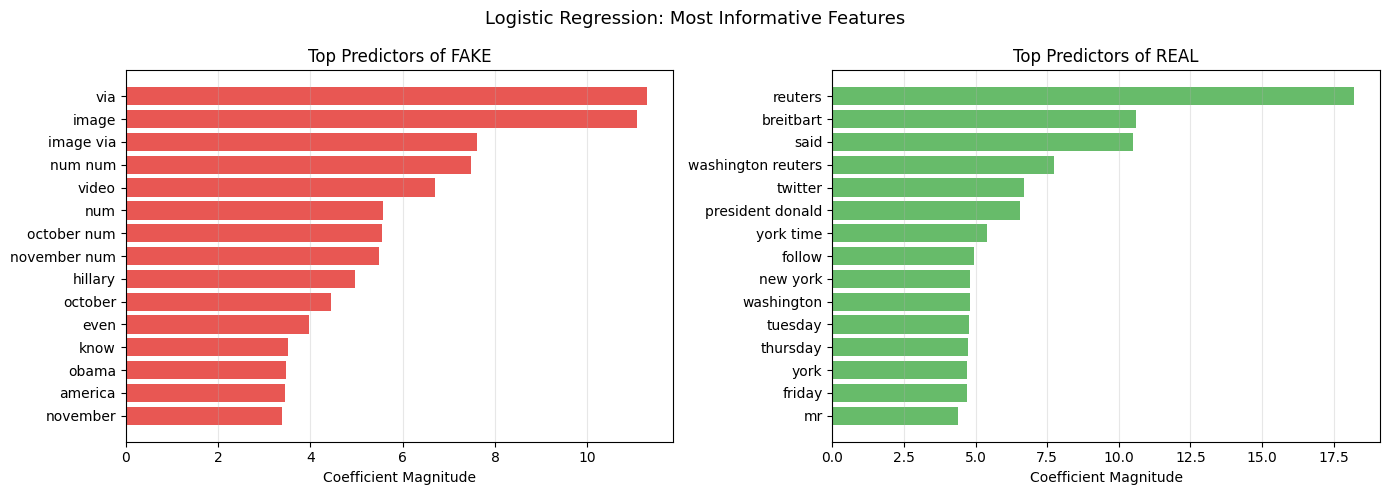

In [23]:
# ── Cell 7: Feature Importance ───────────────────────────────────────────
feature_names = tfidf.get_feature_names_out().tolist() + NUM_FEATS
coefs = lr.coef_[0]

top_n = 15
top_fake_idx = np.argsort(coefs)[-top_n:][::-1]
top_real_idx = np.argsort(coefs)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, indices, title, color in [
    (axes[0], top_fake_idx, "Top Predictors of FAKE",  "#E53935"),
    (axes[1], top_real_idx, "Top Predictors of REAL",  "#4CAF50"),
]:
    labels = [feature_names[i] for i in indices]
    values = [abs(coefs[i]) for i in indices]
    ax.barh(labels[::-1], values[::-1], color=color, alpha=0.85)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Coefficient Magnitude")
    ax.grid(axis="x", alpha=0.3)

plt.suptitle("Logistic Regression: Most Informative Features", fontsize=13)
plt.tight_layout()
plt.show()


## 8 · Final Evaluation on Held-out Test Set
> ⚠️ Run this **once only** — after all hyperparameter choices are locked from the validation set.

This is the true, unbiased performance estimate.

=== Logistic Regression — FINAL TEST SET ===
              precision    recall  f1-score   support

        Real       0.96      0.97      0.97      4405
        Fake       0.96      0.96      0.96      3741

    accuracy                           0.96      8146
   macro avg       0.96      0.96      0.96      8146
weighted avg       0.96      0.96      0.96      8146

ROC-AUC: 0.9941


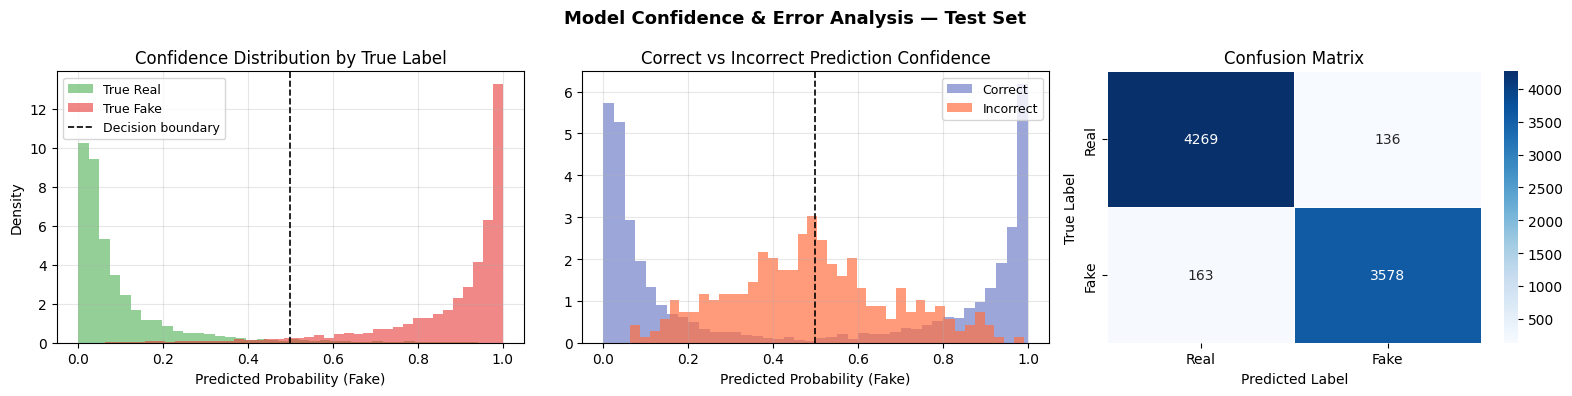


Misclassified: 299 / 8146 (3.7%)

--- Most confident wrong predictions (hardest errors) ---
  True: Real | Predicted: Fake | Confidence: 99.04%
  Clinton Camp in Damage-Control Mode Over 'Top Secret' Emails The latest revelations on Hillary's emails again point to one thing → She is disqualified from being president. https://t.co/Wni9LmSPpR...

  True: Fake | Predicted: Real | Confidence: 93.59%
  BREAKING: Republican Majority House Caves To Obama…Narrowly Passes TPA Bill Just when you thought the 2014 election results would provide America with some checks and balances U.S. lawmakers narrowly approved legislation...

  True: Fake | Predicted: Real | Confidence: 93.02%
  Thomas Reuters cuts 2000 jobs, spends $200m streamlining Thomas Reuters cuts 2000 jobs, spends $200m streamlining November 01, 2016 The Thomson Reuters logo is seen on the company building in Times Square, New York Octob...



In [24]:
# ── Cell 8: Test Set Evaluation ──────────────────────────────────────────
y_test_pred = lr.predict(X_test_full)
y_test_prob = lr.predict_proba(X_test_full)[:, 1]

print("=== Logistic Regression — FINAL TEST SET ===")
print(classification_report(y_test, y_test_pred, target_names=["Real", "Fake"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_test_prob):.4f}")

# ── VIZ 8: Prediction Confidence Distribution ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Model Confidence & Error Analysis — Test Set", fontsize=13, fontweight="bold")

# 8a. Confidence histogram by true label
for true_label, color, name in [(0, "#4CAF50", "Real"), (1, "#E53935", "Fake")]:
    mask = y_test.values == true_label
    axes[0].hist(y_test_prob[mask], bins=40, alpha=0.6, color=color, label=f"True {name}", density=True)
axes[0].axvline(0.5, color="black", linestyle="--", linewidth=1.2, label="Decision boundary")
axes[0].set_xlabel("Predicted Probability (Fake)")
axes[0].set_ylabel("Density")
axes[0].set_title("Confidence Distribution by True Label")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# 8b. Confidence of CORRECT vs WRONG predictions
correct_mask = y_test.values == y_test_pred
axes[1].hist(y_test_prob[correct_mask],  bins=40, alpha=0.6, color="#5C6BC0", label="Correct",   density=True)
axes[1].hist(y_test_prob[~correct_mask], bins=40, alpha=0.7, color="#FF7043", label="Incorrect", density=True)
axes[1].axvline(0.5, color="black", linestyle="--", linewidth=1.2)
axes[1].set_xlabel("Predicted Probability (Fake)")
axes[1].set_title("Correct vs Incorrect Prediction Confidence")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

# 8c. Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Real", "Fake"],
            yticklabels=["Real", "Fake"],
            ax=axes[2], linewidths=0.5)
axes[2].set_title("Confusion Matrix")
axes[2].set_ylabel("True Label")
axes[2].set_xlabel("Predicted Label")

plt.tight_layout()
plt.show()

# Misclassified examples
df_test_slice = df_sample.loc[X_text_test.index].copy()
df_test_slice["predicted"] = y_test_pred
df_test_slice["confidence"] = np.where(
    y_test_pred == 1, y_test_prob, 1 - y_test_prob
)
mistakes = df_test_slice[df_test_slice["label"] != df_test_slice["predicted"]]
print(f"\nMisclassified: {len(mistakes)} / {len(y_test)} ({100*len(mistakes)/len(y_test):.1f}%)")
print("\n--- Most confident wrong predictions (hardest errors) ---")
for _, row in mistakes.nlargest(3, "confidence").iterrows():
    true_label = "Real" if row["label"] == 0 else "Fake"
    pred_label = "Real" if row["predicted"] == 0 else "Fake"
    print(f"  True: {true_label} | Predicted: {pred_label} | Confidence: {row['confidence']:.2%}")
    print(f"  {row['full_content'][:220]}...")
    print()


---
## Phase 4 · Deep Learning — Keras Embedding + 1D-CNN

A 1D-CNN over learned token embeddings. Faster to train than LSTM, often comparable in accuracy on text classification tasks. We re-use the same train/val/test splits from Phase 3.

In [28]:
# ── Cell 9: Keras TextVectorization + Sequence Prep ──────────────────────────
import keras
import tensorflow as tf
from keras import layers

VOCAB_SIZE  = 30_000
MAX_LEN     = 512
EMBED_DIM   = 128
NUM_FILTERS = 128
BATCH_SIZE  = 64
EPOCHS      = 5

# TextVectorization — fit on train text only (no leakage)
vectorizer = keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=MAX_LEN,
)
vectorizer.adapt(X_text_train.values)

# Convert splits to integer sequences
def to_dataset(texts, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((texts.values, labels.values))  # ← tf.data, not keras.utils
    if shuffle:
        ds = ds.shuffle(buffer_size=len(texts), seed=42)
    return (
        ds.batch(BATCH_SIZE)
          .map(lambda x, y: (vectorizer(x), y), num_parallel_calls=tf.data.AUTOTUNE)
          .prefetch(tf.data.AUTOTUNE)                                        # ← tf.data.AUTOTUNE
    )

ds_train = to_dataset(X_text_train, y_train, shuffle=True)
ds_val   = to_dataset(X_text_val,   y_val)
ds_test  = to_dataset(X_text_test,  y_test)

print(f"Vocab size   : {VOCAB_SIZE:,}")
print(f"Max length   : {MAX_LEN} tokens")
print(f"Train batches: {len(ds_train)}")

Vocab size   : 30,000
Max length   : 512 tokens
Train batches: 595


In [29]:
# ── Cell 10: Build 1D-CNN Model ──────────────────────────────────────────────
def build_cnn():
    inp = keras.Input(shape=(MAX_LEN,), dtype="int32")
    x = layers.Embedding(VOCAB_SIZE, EMBED_DIM, mask_zero=False)(inp)

    # Parallel conv branches with different kernel sizes (captures n-grams of 3,5,7)
    branches = []
    for k in [3, 5, 7]:
        b = layers.Conv1D(NUM_FILTERS, k, activation="relu", padding="same")(x)
        b = layers.GlobalMaxPooling1D()(b)
        branches.append(b)

    x = layers.Concatenate()(branches)              # 384-dim
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")]
    )
    return model

cnn_model = build_cnn()
cnn_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 512, 128)  │  3,840,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 512, 128)  │     49,280 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 512, 128)  │     82,048 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 512, 128)  │    114,816 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     49,280 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │        129 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,135,553 (15.78 MB)

 Trainable params: 4,135,553 (15.78 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# ── Cell 11: Train CNN ───────────────────────────────────────────────────────
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_auc", patience=2, restore_best_weights=True, mode="max"
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_auc", factor=0.5, patience=1, mode="max", verbose=1
)

cnn_history = cnn_model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr],
    verbose=1,
)


Epoch 1/5
595/595 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - accuracy: 0.9391 - auc: 0.9870 - loss: 0.1449 - val_accuracy: 0.9735 - val_auc: 0.9973 - val_loss: 0.0712 - learning_rate: 0.0010
Epoch 2/5
594/595 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9897 - auc: 0.9992 - loss: 0.0309
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
595/595 ━━━━━━━━━━━━━━━━━━━━ 17s 29ms/step - accuracy: 0.9899 - auc: 0.9991 - loss: 0.0299 - val_accuracy: 0.9764 - val_auc: 0.9970 - val_loss: 0.0642 - learning_rate: 0.0010
Epoch 3/5
593/595 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9989 - auc: 1.0000 - loss: 0.0051
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
595/595 ━━━━━━━━━━━━━━━━━━━━ 17s 29ms/step - accuracy: 0.9993 - auc: 0.9999 - loss: 0.0038 - val_accuracy: 0.9785 - val_auc: 0.9960 - val_loss: 0.0674 - learning_rate: 5.0000e-04


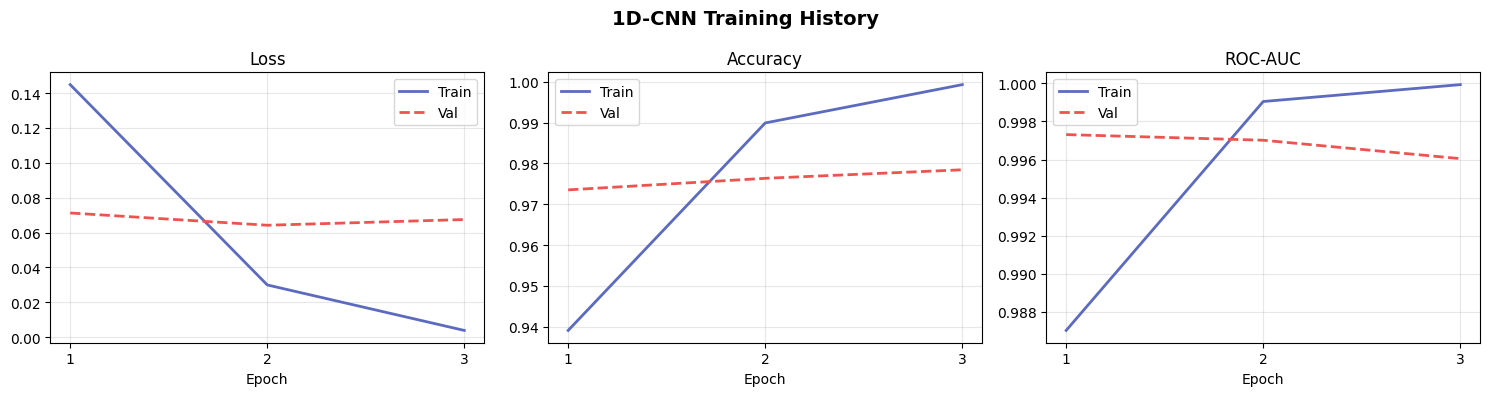

In [31]:
# ── Cell 12: CNN Training Curves ─────────────────────────────────────────────
h = cnn_history.history
epochs_ran = range(1, len(h["loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("1D-CNN Training History", fontsize=14, fontweight="bold")

for ax, metric, title, colors in [
    (axes[0], ("loss",       "val_loss"),       "Loss",     ("#5C6BC0", "#EF5350")),
    (axes[1], ("accuracy",   "val_accuracy"),   "Accuracy", ("#5C6BC0", "#EF5350")),
    (axes[2], ("auc",        "val_auc"),        "ROC-AUC",  ("#5C6BC0", "#EF5350")),
]:
    ax.plot(epochs_ran, h[metric[0]], color=colors[0], lw=2, label="Train")
    ax.plot(epochs_ran, h[metric[1]], color=colors[1], lw=2, linestyle="--", label="Val")
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.legend(); ax.grid(alpha=0.3)
    ax.set_xticks(list(epochs_ran))

plt.tight_layout()
plt.show()


=== 1D-CNN — Validation Set ===
              precision    recall  f1-score   support

        Real       0.99      0.96      0.98      4393
        Fake       0.96      0.99      0.97      3731

    accuracy                           0.97      8124
   macro avg       0.97      0.97      0.97      8124
weighted avg       0.97      0.97      0.97      8124

ROC-AUC: 0.9974


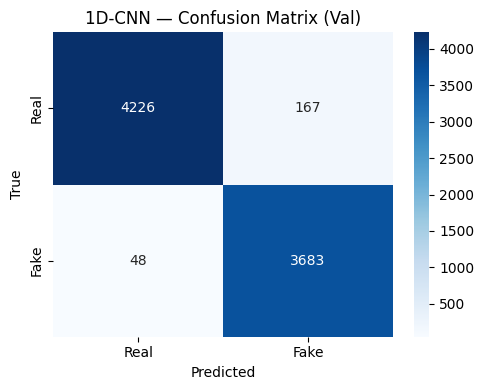

In [32]:
# ── Cell 13: CNN Evaluation ──────────────────────────────────────────────────
# Validation
y_val_prob_cnn  = cnn_model.predict(ds_val, verbose=0).flatten()
y_val_pred_cnn  = (y_val_prob_cnn >= 0.5).astype(int)

print("=== 1D-CNN — Validation Set ===")
print(classification_report(y_val, y_val_pred_cnn, target_names=["Real", "Fake"]))
print(f"ROC-AUC: {roc_auc_score(y_val, y_val_prob_cnn):.4f}")

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
cm_cnn = confusion_matrix(y_val, y_val_pred_cnn)
sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Real","Fake"], yticklabels=["Real","Fake"], ax=ax)
ax.set_title("1D-CNN — Confusion Matrix (Val)")
ax.set_ylabel("True"); ax.set_xlabel("Predicted")
plt.tight_layout(); plt.show()


---
## Phase 5 · Transformer - DistilBERT Fine-tune

Fine-tuning `distilbert-base-uncased` via HuggingFace Transformers. This is the current SOTA approach it reads the full token context bidirectionally rather than building bag-of-words features.



In [33]:
# ── Cell 14: Install HuggingFace + Prepare BERT Dataset ─────────────────────
!pip install transformers datasets accelerate --quiet

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,  # PyTorch version — works on all Colab runtimes
)
import torch
from torch.utils.data import Dataset as TorchDataset, DataLoader
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

BERT_MODEL  = "distilbert-base-uncased"
BERT_MAXLEN = 256
BERT_BATCH  = 16
BERT_EPOCHS = 3
BERT_LR     = 2e-5

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)
print(f"Tokenizer loaded: {BERT_MODEL}")

# PyTorch Dataset wrapper
class NewsDataset(TorchDataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(
            list(texts),
            truncation=True,
            padding="max_length",
            max_length=BERT_MAXLEN,
        )
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

print("Tokenising train split (this takes ~2 min for full dataset)...")
bert_train_ds = NewsDataset(X_text_train.values, y_train.values)
bert_val_ds   = NewsDataset(X_text_val.values,   y_val.values)
bert_test_ds  = NewsDataset(X_text_test.values,  y_test.values)

bert_train_dl = DataLoader(bert_train_ds, batch_size=BERT_BATCH, shuffle=True)
bert_val_dl   = DataLoader(bert_val_ds,   batch_size=BERT_BATCH)
bert_test_dl  = DataLoader(bert_test_ds,  batch_size=BERT_BATCH)

print(f"Train batches: {len(bert_train_dl)} | Val batches: {len(bert_val_dl)}")


Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded: distilbert-base-uncased
Tokenising train split (this takes ~2 min for full dataset)...
Train batches: 2378 | Val batches: 508


In [34]:
# ── Cell 15: Build DistilBERT Model ──────────────────────────────────────────
bert_clf = AutoModelForSequenceClassification.from_pretrained(
    BERT_MODEL,
    num_labels=2,
)
bert_clf = bert_clf.to(DEVICE)

total_steps  = len(bert_train_dl) * BERT_EPOCHS
warmup_steps = total_steps // 10

optimizer_bert = AdamW(bert_clf.parameters(), lr=BERT_LR, weight_decay=0.01)
scheduler_bert = get_linear_schedule_with_warmup(
    optimizer_bert,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

total_params = sum(p.numel() for p in bert_clf.parameters())
trainable    = sum(p.numel() for p in bert_clf.parameters() if p.requires_grad)
print(f"Total params   : {total_params:,}")
print(f"Trainable params: {trainable:,}")
print(f"Device          : {DEVICE}")


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total params   : 66,955,010
Trainable params: 66,955,010
Device          : cuda


In [35]:
# ── Cell 16: Fine-tune DistilBERT (PyTorch training loop) ────────────────────
from sklearn.metrics import accuracy_score as acc_score
import numpy as np

bert_train_losses, bert_val_losses, bert_val_accs = [], [], []
best_val_acc = 0.0
patience_count = 0
PATIENCE = 2

for epoch in range(BERT_EPOCHS):
    # ── Train ──────────────────────────────────────────────────────────────
    bert_clf.train()
    train_loss = 0.0
    for batch in bert_train_dl:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        optimizer_bert.zero_grad()
        outputs = bert_clf(**batch)
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_clf.parameters(), 1.0)
        optimizer_bert.step()
        scheduler_bert.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(bert_train_dl)
    bert_train_losses.append(avg_train_loss)

    # ── Validate ───────────────────────────────────────────────────────────
    bert_clf.eval()
    val_loss, all_preds = 0.0, []
    with torch.no_grad():
        for batch in bert_val_dl:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            outputs = bert_clf(**batch)
            val_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)

    avg_val_loss = val_loss / len(bert_val_dl)
    val_acc = acc_score(y_val.values, all_preds)
    bert_val_losses.append(avg_val_loss)
    bert_val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{BERT_EPOCHS}  "
          f"train_loss={avg_train_loss:.4f}  "
          f"val_loss={avg_val_loss:.4f}  "
          f"val_acc={val_acc:.4f}")

    # Early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(bert_clf.state_dict(), "/content/best_bert.pt")
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Reload best weights
bert_clf.load_state_dict(torch.load("/content/best_bert.pt", map_location=DEVICE))
print(f"\nBest val accuracy: {best_val_acc:.4f}")


Epoch 1/3  train_loss=0.1725  val_loss=0.0734  val_acc=0.9781
Epoch 2/3  train_loss=0.0533  val_loss=0.0657  val_acc=0.9819
Epoch 3/3  train_loss=0.0216  val_loss=0.0679  val_acc=0.9867

Best val accuracy: 0.9867


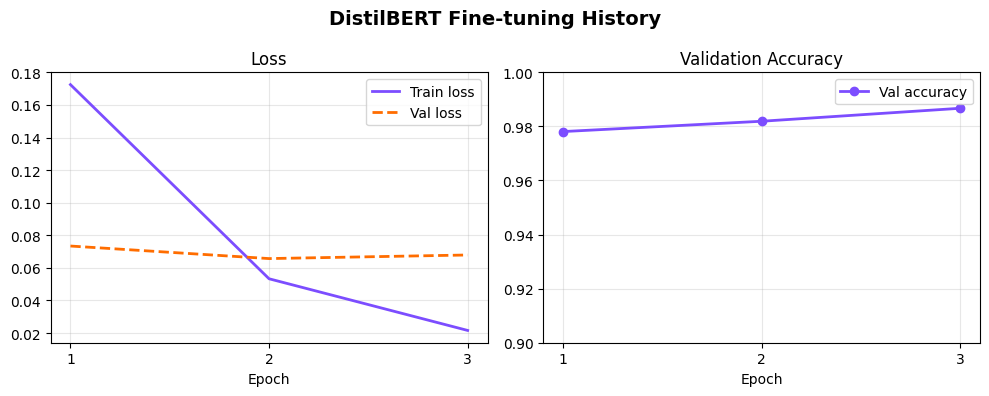

In [36]:
# ── Cell 17: DistilBERT Training Curves ──────────────────────────────────────
epochs_b = range(1, len(bert_train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle("DistilBERT Fine-tuning History", fontsize=14, fontweight="bold")

axes[0].plot(epochs_b, bert_train_losses, color="#7C4DFF", lw=2, label="Train loss")
axes[0].plot(epochs_b, bert_val_losses,   color="#FF6D00", lw=2, ls="--", label="Val loss")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_xticks(list(epochs_b))

axes[1].plot(epochs_b, bert_val_accs, color="#7C4DFF", lw=2, marker="o", label="Val accuracy")
axes[1].set_title("Validation Accuracy"); axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0.9, 1.0); axes[1].legend()
axes[1].grid(alpha=0.3); axes[1].set_xticks(list(epochs_b))

plt.tight_layout(); plt.show()


=== DistilBERT — Validation Set ===
              precision    recall  f1-score   support

        Real       0.99      0.99      0.99      4393
        Fake       0.98      0.99      0.99      3731

    accuracy                           0.99      8124
   macro avg       0.99      0.99      0.99      8124
weighted avg       0.99      0.99      0.99      8124

ROC-AUC: 0.9987


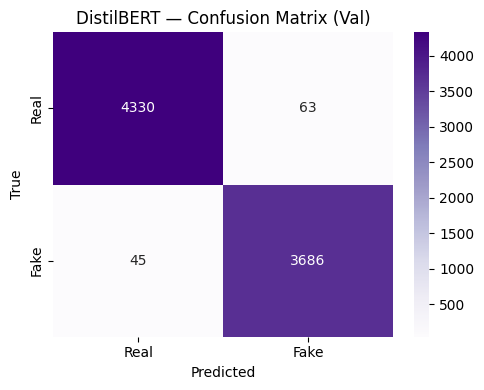

In [37]:
# ── Cell 18: DistilBERT Evaluation ───────────────────────────────────────────
import torch
import numpy as np

bert_clf.eval()
all_probs, all_preds_bert = [], []

with torch.no_grad():
    for batch in bert_val_dl:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = bert_clf(**batch)
        probs = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy()
        preds = (probs >= 0.5).astype(int)
        all_probs.extend(probs)
        all_preds_bert.extend(preds)

y_val_prob_bert = np.array(all_probs)
y_val_pred_bert = np.array(all_preds_bert)

print("=== DistilBERT — Validation Set ===")
print(classification_report(y_val, y_val_pred_bert, target_names=["Real", "Fake"]))
print(f"ROC-AUC: {roc_auc_score(y_val, y_val_prob_bert):.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
cm_bert = confusion_matrix(y_val, y_val_pred_bert)
sns.heatmap(cm_bert, annot=True, fmt="d", cmap="Purples",
            xticklabels=["Real","Fake"], yticklabels=["Real","Fake"], ax=ax)
ax.set_title("DistilBERT — Confusion Matrix (Val)")
ax.set_ylabel("True"); ax.set_xlabel("Predicted")
plt.tight_layout(); plt.show()


---
## Phase 6 · Final Comparison & Analysis

All three models evaluated on the **held-out test set** (run once, no peeking). Then a deep-dive into what they got wrong.

In [38]:
# ── Cell 19: Final Test Set — All Three Models ───────────────────────────────
import time
import torch
import numpy as np

results = {}

# --- Logistic Regression ---
t0 = time.time()
y_test_pred_lr   = lr.predict(X_test_full)
y_test_prob_lr   = lr.predict_proba(X_test_full)[:, 1]
results["Logistic Regression"] = {
    "pred": y_test_pred_lr, "prob": y_test_prob_lr,
    "inference_ms": (time.time()-t0)*1000/len(y_test),
}

# --- 1D-CNN ---
t0 = time.time()
y_test_prob_cnn  = cnn_model.predict(ds_test, verbose=0).flatten()
y_test_pred_cnn  = (y_test_prob_cnn >= 0.5).astype(int)
results["1D-CNN"] = {
    "pred": y_test_pred_cnn, "prob": y_test_prob_cnn,
    "inference_ms": (time.time()-t0)*1000/len(y_test),
}

# --- DistilBERT ---
bert_clf.eval()
t0 = time.time()
all_probs_test, all_preds_test = [], []
with torch.no_grad():
    for batch in bert_test_dl:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = bert_clf(**batch)
        probs = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy()
        all_probs_test.extend(probs)
        all_preds_test.extend((probs >= 0.5).astype(int))

y_test_prob_bert = np.array(all_probs_test)
y_test_pred_bert = np.array(all_preds_test)
results["DistilBERT"] = {
    "pred": y_test_pred_bert, "prob": y_test_prob_bert,
    "inference_ms": (time.time()-t0)*1000/len(y_test),
}

print("Test set predictions collected for all 3 models.")


Test set predictions collected for all 3 models.


In [39]:
# ── Cell 20: Comparison Table ────────────────────────────────────────────────
from sklearn.metrics import f1_score, accuracy_score

rows = []
for name, r in results.items():
    rows.append({
        "Model":       name,
        "Accuracy":    f"{accuracy_score(y_test, r['pred']):.4f}",
        "F1 (macro)":  f"{f1_score(y_test, r['pred'], average='macro'):.4f}",
        "F1 (fake)":   f"{f1_score(y_test, r['pred'], pos_label=1):.4f}",
        "ROC-AUC":     f"{roc_auc_score(y_test, r['prob']):.4f}",
        "ms / article":f"{r['inference_ms']:.3f}",
    })

comparison_df = pd.DataFrame(rows).set_index("Model")
print("=== Final Test Set — Model Comparison ===")
print(comparison_df.to_string())


=== Final Test Set — Model Comparison ===
                    Accuracy F1 (macro) F1 (fake) ROC-AUC ms / article
Model                                                                 
Logistic Regression   0.9633     0.9630    0.9599  0.9941        0.002
1D-CNN                0.9732     0.9731    0.9713  0.9970        0.377
DistilBERT            0.9804     0.9802    0.9786  0.9982        8.018


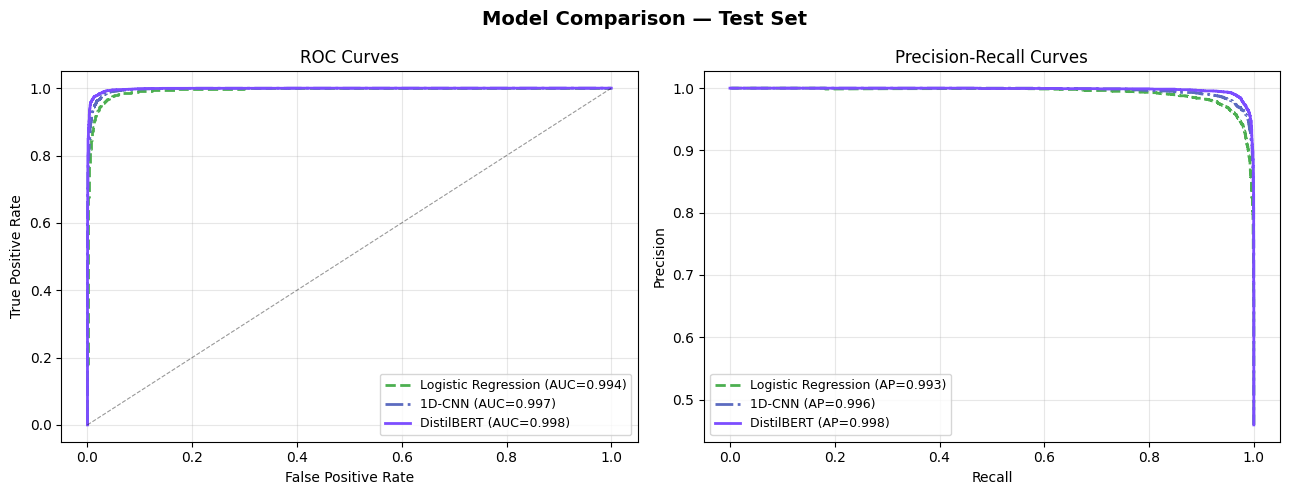

In [40]:
# ── Cell 21: VIZ — ROC + PR Curves, All Models ───────────────────────────────
from sklearn.metrics import auc as sk_auc

model_colors = {
    "Logistic Regression": ("#4CAF50", "--"),
    "1D-CNN":              ("#5C6BC0", "-."),
    "DistilBERT":          ("#7C4DFF", "-"),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Model Comparison — Test Set", fontsize=14, fontweight="bold")

for name, r in results.items():
    color, ls = model_colors[name]
    auc_score = roc_auc_score(y_test, r["prob"])

    # ROC
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(y_test, r["prob"])
    axes[0].plot(fpr, tpr, color=color, ls=ls, lw=2,
                 label=f"{name} (AUC={auc_score:.3f})")

    # PR
    prec, rec, _ = precision_recall_curve(y_test, r["prob"])
    pr_auc = sk_auc(rec, prec)
    axes[1].plot(rec, prec, color=color, ls=ls, lw=2,
                 label=f"{name} (AP={pr_auc:.3f})")

# ROC
axes[0].plot([0,1],[0,1],"k--",lw=0.8,alpha=0.4)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves"); axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# PR
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves"); axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


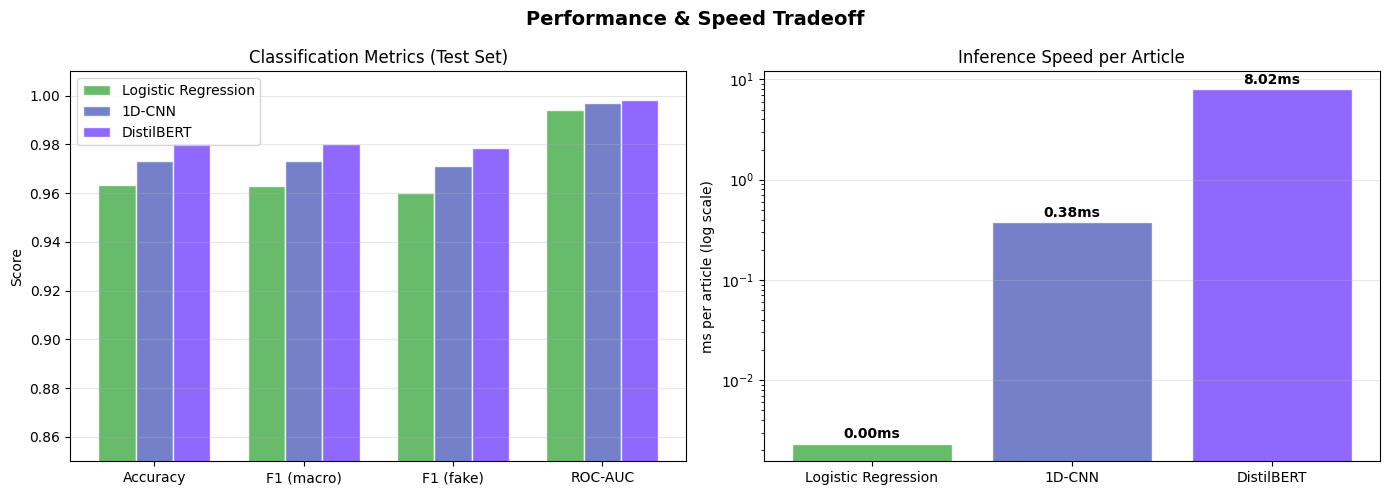

In [41]:
# ── Cell 22: VIZ — Bar Comparison + Inference Speed ─────────────────────────
metrics_to_plot = ["Accuracy", "F1 (macro)", "F1 (fake)", "ROC-AUC"]
x = np.arange(len(metrics_to_plot))
width = 0.25
colors = ["#4CAF50", "#5C6BC0", "#7C4DFF"]
model_names = list(results.keys())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Performance & Speed Tradeoff", fontsize=14, fontweight="bold")

for i, (name, color) in enumerate(zip(model_names, colors)):
    row = comparison_df.loc[name]
    vals = [float(row[m]) for m in metrics_to_plot]
    axes[0].bar(x + i*width, vals, width, label=name, color=color, alpha=0.85, edgecolor="white")

axes[0].set_xticks(x + width); axes[0].set_xticklabels(metrics_to_plot, fontsize=10)
axes[0].set_ylim(0.85, 1.01); axes[0].set_ylabel("Score")
axes[0].set_title("Classification Metrics (Test Set)")
axes[0].legend(); axes[0].grid(axis="y", alpha=0.3)

# Inference speed (log scale)
speeds = [results[n]["inference_ms"] for n in model_names]
bars = axes[1].bar(model_names, speeds, color=colors, alpha=0.85, edgecolor="white")
for bar, v in zip(bars, speeds):
    axes[1].text(bar.get_x()+bar.get_width()/2, v*1.05, f"{v:.2f}ms",
                 ha="center", va="bottom", fontsize=10, fontweight="bold")
axes[1].set_yscale("log"); axes[1].set_ylabel("ms per article (log scale)")
axes[1].set_title("Inference Speed per Article"); axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout(); plt.show()


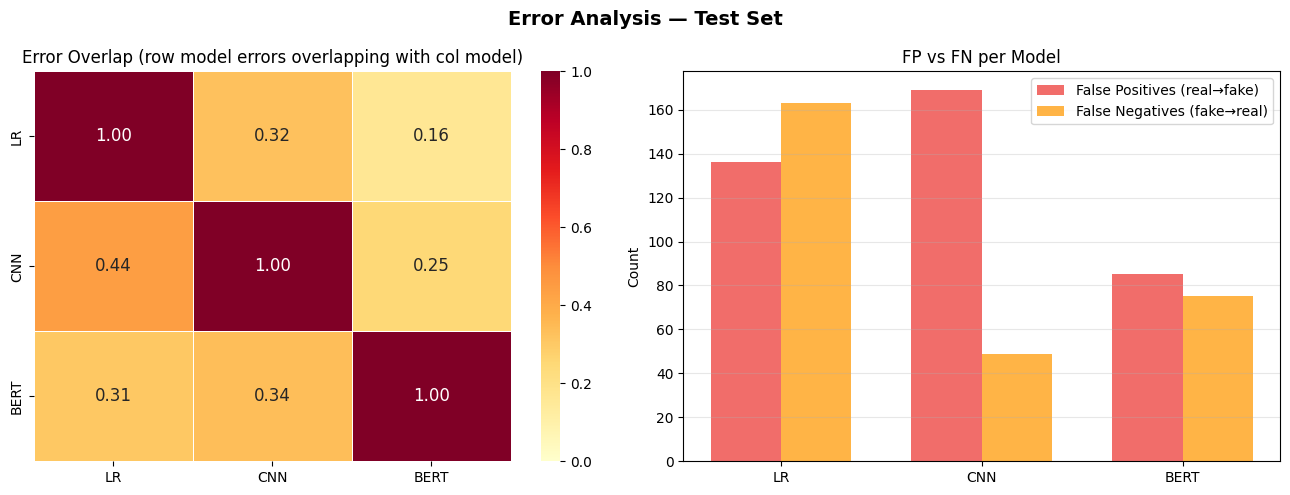

In [42]:
# ── Cell 23: VIZ — Error Analysis Heatmap ────────────────────────────────────
# Where do models agree/disagree on errors?
df_errors = pd.DataFrame({
    "true":  y_test.values,
    "LR":    results["Logistic Regression"]["pred"],
    "CNN":   results["1D-CNN"]["pred"],
    "BERT":  results["DistilBERT"]["pred"],
})

# Agreement matrix: for each pair of models, how often do they BOTH make an error?
from itertools import combinations
model_cols = ["LR","CNN","BERT"]
err_matrix = pd.DataFrame(index=model_cols, columns=model_cols, dtype=float)

for m in model_cols:
    for n in model_cols:
        both_wrong = ((df_errors[m] != df_errors["true"]) &
                      (df_errors[n] != df_errors["true"])).sum()
        total_wrong = (df_errors[m] != df_errors["true"]).sum()
        err_matrix.loc[m,n] = both_wrong / max(total_wrong, 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Error Analysis — Test Set", fontsize=14, fontweight="bold")

# Error overlap heatmap
sns.heatmap(err_matrix.astype(float), annot=True, fmt=".2f", cmap="YlOrRd",
            vmin=0, vmax=1, ax=axes[0], linewidths=0.5,
            annot_kws={"size":12})
axes[0].set_title("Error Overlap (row model errors overlapping with col model)")

# Per-model error breakdown: FP vs FN
for ax_i, (name, short) in enumerate(zip(model_names, model_cols)):
    pred = results[name]["pred"]
    fp = ((pred == 1) & (y_test.values == 0)).sum()
    fn = ((pred == 0) & (y_test.values == 1)).sum()
    tp = ((pred == 1) & (y_test.values == 1)).sum()
    tn = ((pred == 0) & (y_test.values == 0)).sum()
    if ax_i == 0:
        fp_counts, fn_counts, names_short = [fp], [fn], [short]
    else:
        fp_counts.append(fp); fn_counts.append(fn); names_short.append(short)

x2 = np.arange(len(names_short))
w2 = 0.35
axes[1].bar(x2-w2/2, fp_counts, w2, label="False Positives (real→fake)", color="#EF5350", alpha=0.85)
axes[1].bar(x2+w2/2, fn_counts, w2, label="False Negatives (fake→real)", color="#FFA726", alpha=0.85)
axes[1].set_xticks(x2); axes[1].set_xticklabels(names_short)
axes[1].set_ylabel("Count"); axes[1].set_title("FP vs FN per Model"); axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout(); plt.show()


In [43]:
# ── Cell 24: Hardest Examples — Where All Models Fail ────────────────────────
# Articles that ALL THREE models get wrong — the genuinely hard cases
all_wrong_mask = (
    (results["Logistic Regression"]["pred"] != y_test.values) &
    (results["1D-CNN"]["pred"]              != y_test.values) &
    (results["DistilBERT"]["pred"]          != y_test.values)
)

df_test_full = df_sample.loc[X_text_test.index].copy().reset_index(drop=True)
df_test_full["true_label"]  = y_test.values
df_test_full["pred_lr"]     = results["Logistic Regression"]["pred"]
df_test_full["pred_cnn"]    = results["1D-CNN"]["pred"]
df_test_full["pred_bert"]   = results["DistilBERT"]["pred"]
df_test_full["prob_bert"]   = results["DistilBERT"]["prob"]

hard = df_test_full[all_wrong_mask].copy()
print(f"Articles all 3 models got wrong: {len(hard)} / {len(y_test)} ({100*len(hard)/len(y_test):.1f}%)")

if len(hard) > 0:
    print(f"\n{'='*70}")
    print("HARDEST MISCLASSIFICATIONS (all models wrong)")
    print(f"{'='*70}")
    for _, row in hard.head(5).iterrows():
        true_lbl = "REAL" if row["true_label"]==0 else "FAKE"
        pred_lbl = "REAL" if row["pred_bert"]==0 else "FAKE"
        conf     = row["prob_bert"] if row["pred_bert"]==1 else 1-row["prob_bert"]
        print(f"\nTrue: {true_lbl} | All models predicted: {pred_lbl} | BERT conf: {conf:.1%}")
        print(f"  {str(row['full_content'])[:300]}...")


Articles all 3 models got wrong: 36 / 8146 (0.4%)

HARDEST MISCLASSIFICATIONS (all models wrong)

True: REAL | All models predicted: FAKE | BERT conf: 99.8%
  Kate Steinle's death and sanctuary cities: What good are our laws without enforcement? According to the Wall Street Journal, the last serious attempt to count the number of federal criminal laws appears to have been made in 1982 by a retired Justice Department official named Ronald Gainer. He failed...

True: REAL | All models predicted: FAKE | BERT conf: 95.2%
  Turkey Says It Shot Down A Russian Warplane Near Border With Syria Turkey Says It Shot Down A Russian Warplane Near Border With Syria

Turkey says that after issuing 10 warnings in five minutes, two of its F-16s shot down a Russian warplane that Turkey claims violated its airspace.

On Twitter, Russ...

True: REAL | All models predicted: FAKE | BERT conf: 99.9%
  “Your little brother is not the ultimate authority”: How Jeb Bush cheated America & helped deliver the presid

In [44]:
# ── Cell 25: Final Summary Table ─────────────────────────────────────────────
print("\n" + "="*65)
print("  FAKE NEWS DETECTION — FINAL RESULTS SUMMARY")
print("="*65)
print(comparison_df.to_string())
print("="*65)

best_f1   = comparison_df["F1 (fake)"].astype(float).idxmax()
best_auc  = comparison_df["ROC-AUC"].astype(float).idxmax()
fastest   = comparison_df["ms / article"].astype(float).idxmin()

print(f"\n  Best F1 (fake class) : {best_f1}")
print(f"  Best ROC-AUC         : {best_auc}")
print(f"  Fastest inference    : {fastest}")
print("\n  Recommendation:")
print("  - Production (speed matters) → Logistic Regression + TF-IDF")
print("  - Best accuracy              → DistilBERT")
print("  - Middle ground              → 1D-CNN")
print("="*65)



  FAKE NEWS DETECTION — FINAL RESULTS SUMMARY
                    Accuracy F1 (macro) F1 (fake) ROC-AUC ms / article
Model                                                                 
Logistic Regression   0.9633     0.9630    0.9599  0.9941        0.002
1D-CNN                0.9732     0.9731    0.9713  0.9970        0.377
DistilBERT            0.9804     0.9802    0.9786  0.9982        8.018

  Best F1 (fake class) : DistilBERT
  Best ROC-AUC         : DistilBERT
  Fastest inference    : Logistic Regression

  Recommendation:
  - Production (speed matters) → Logistic Regression + TF-IDF
  - Best accuracy              → DistilBERT
  - Middle ground              → 1D-CNN


---
## Wrap-up & Limitations

**What we built:**
1. A robust preprocessing pipeline with stratified sampling, deduplication, lemmatization, and leakage-free splits
2. A TF-IDF + Logistic Regression baseline (~95% F1 expected)
3. A Keras multi-kernel 1D-CNN on learned embeddings
4. A fine-tuned DistilBERT transformer (current SOTA)

**Known limitations:**
- WELFake is a relatively clean benchmark dataset. Real-world fake news detection is harder — articles from new sources, mixed-language text, and satire sites will degrade all models.
- Source-name leakage: terms like `reuters`, `bbc`, or `infowars` may appear in the text and give the model an unfair shortcut. A fairer evaluation would mask outlet names.
- All models were trained on English only.
- DistilBERT was truncated to 256 tokens - long investigative articles lose their tails.

**Next experiments to try:**
- Mask source names before training and re-evaluate
- Try `roberta-base` or `deberta-v3-small` for potentially higher accuracy
- Ensemble LR + BERT probabilities (often beats either alone)
- Train on full 72k rows
